**Goal.** Assemble all static artifacts into a single `.npz` consumed by the Graph dataloader.

**What this notebook does**
1. Loads the mesh (nodes + optional edges) and the static channels from steps 01–02.
2. Aligns tensors and checks shapes.
3. Adds graph connectivity (base horizontal edges) if not already present.
4. Packs everything into `graph_static_from_stats_vgeo_aligned.npz`.

**Expected keys (consumed by the dataloader)**
- `coord_lon[N]`, `coord_lat[N]` — node coordinates (degrees).
- `static_geo_mesh[N,4]` — four static channels (already normalized if desired).
- `static_pos2d_mesh[4,N]` — 2D positional encoding (optional; otherwise it will be computed on‑the‑fly).
- One of the following for edges:
  - `edge_index_horiz_base[2, Eh]` *(preferred)*
  - or `edge_index_horiz[2, E_total]` with `horiz_edge_ptr[L+1]` (slice level 0)
  - or legacy: `edges_h_src`/`edges_h_dst` or `edges_horiz`
- Optional metadata: `levels`, `level_offsets`, `mesh_hash`.

**Output file**
- `./data/graph/graph_static_from_stats_vgeo_aligned.npz`

In [1]:
import os

from __future__ import annotations
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import json, hashlib
import numpy as np

In [3]:
MESH_NPZ    = Path(r"./data/mesh/multiscale_jigsaw_ll.npz")   # contains verts_ll, tris
STATIC_ROOT = Path(r"./data/static")                           # subfolders: 1/, 05/, 025/ each with geo_pos_static.npz
STATS_JSON  = Path(r"./data/stats/stats_1deg_1980_2013.json")
OUT_BASE    = Path(r"./data/graph/graph_static_from_stats.npz")  # final will be *_vgeo_aligned.npz

# -------- Region-of-interest and ring (MUST match your mesh build)
# ROI bounds: (lon_min, lon_max, lat_min, lat_max)
ROI_BOUNDS = (-11.0, 2.0, 49.0, 59.0)
# Ring padding around ROI: (pad_lon, pad_lat)
RING_PAD   = (6.0, 4.0)

# -------- Constants
EARTH_R_KM = 6371.0
SCHEMA_VERSION = "gstatic_v6"     # bumped: strict verts_ll order + ROI/ring zoning
ZONE_TO_DX = {0:0.25, 1:0.50, 2:1.00}  # ROI / ring / outer (deg)

# -------- Fallbacks (stats.json)
DEFAULT_LEVELS = ["sfc", "850", "500", "300"]
DEFAULT_VBL = {
    "sfc": ["t2m","d2m","msl","u10","v10","tp_log"],
    "850": ["t","r","z","u","v"],
    "500": ["t","r","z","u","v"],
    "300": ["t","r","z","u","v"],
}


In [4]:
# -------- Utilities
def _sha256_of_arrays(arrs: List[np.ndarray]) -> str:
    h = hashlib.sha256()
    for a in arrs: h.update(np.ascontiguousarray(a).data)
    return h.hexdigest()

def _wrap_dlon_rad(dlon):
    twopi = 2.0*np.pi
    return (dlon + np.pi) % twopi - np.pi

def _haversine_km(lon1_deg, lat1_deg, lon2_deg, lat2_deg):
    lon1 = np.radians(lon1_deg); lat1 = np.radians(lat1_deg)
    lon2 = np.radians(lon2_deg); lat2 = np.radians(lat2_deg)
    dlon = _wrap_dlon_rad(lon2 - lon1)
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    c = 2*np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return EARTH_R_KM * c

def _bearing_rad(lon1_deg, lat1_deg, lon2_deg, lat2_deg):
    lon1r = np.radians(lon1_deg); lat1r = np.radians(lat1_deg)
    lon2r = np.radians(lon2_deg); lat2r = np.radians(lat2_deg)
    dlon = _wrap_dlon_rad(lon2r - lon1r)
    y = np.sin(dlon) * np.cos(lat2r)
    x = np.cos(lat1r)*np.cos(lat2r)*np.cos(dlon) + np.sin(lat1r)*np.sin(lat2r)
    return np.arctan2(y, x)

def _triangles_to_edges(tris: np.ndarray, make_undirected: bool=True) -> np.ndarray:
    """Return edge_index [2,E] from triangles [T,3]; duplicates directions if undirected."""
    tris = np.asarray(tris, dtype=np.int64).reshape(-1,3)
    ei = set()
    for a,b,c in tris:
        a,b,c = int(a),int(b),int(c)
        ei.add(tuple(sorted((a,b)))); ei.add(tuple(sorted((b,c)))); ei.add(tuple(sorted((a,c))))
    e = np.array(list(ei), dtype=np.int64).T
    if make_undirected: e = np.concatenate([e, e[::-1,:]], axis=1)
    return e.astype(np.int32)

def _json_from_npz_field(val):
    if isinstance(val, (bytes, bytearray)): val = val.decode("utf-8")
    if hasattr(val, "item"):  val = val.item()
    elif hasattr(val, "tolist"): val = val.tolist()
    if isinstance(val, str): return json.loads(val)
    return val

def _maybe_radians_to_degrees(lon, lat):
    lon = np.asarray(lon); lat = np.asarray(lat)
    max_abs_lon = float(np.nanmax(np.abs(lon)))
    max_abs_lat = float(np.nanmax(np.abs(lat)))
    # If looks like radians, convert to degrees
    if max_abs_lon <= (np.pi + 0.1) and max_abs_lat <= (np.pi/2 + 0.1):
        lon = np.degrees(lon); lat = np.degrees(lat)
    return lon.astype(np.float32), lat.astype(np.float32)

def _load_mesh_npz(path: Path) -> Tuple[np.ndarray,np.ndarray,np.ndarray]:
    """
    STRICT: if 'verts_ll' present, it is interpreted as [lon, lat] in this order.
    Converts radians→degrees if needed. Wraps lon to [-180,180).
    """
    npz = np.load(path, allow_pickle=True)
    keys = set(npz.files)

    if "verts_ll" in keys and ("tris" in keys or "tria" in keys):
        V = np.asarray(npz["verts_ll"])
        tris_key = "tris" if "tris" in keys else "tria"
        tris = np.asarray(npz[tris_key], dtype=np.int64).reshape(-1,3)

        if V.ndim != 2:
            V = V.reshape(-1,2)
        if V.shape[0] == 2 and V.shape[1] != 2:
            V = V.T

        # STRICT: verts_ll = [lon, lat] (this is crucial fix)
        lon_raw = V[:, 0].astype(np.float64)
        lat_raw = V[:, 1].astype(np.float64)

        lon, lat = _maybe_radians_to_degrees(lon_raw, lat_raw)
        lon = ((lon + 180.0) % 360.0) - 180.0
        return lon.reshape(-1), lat.reshape(-1), tris

    # fallback to other key combos
    if all(k in keys for k in ("lon","lat","tris")):
        lon, lat, tris = npz["lon"], npz["lat"], npz["tris"]
    elif all(k in keys for k in ("verts_lon","verts_lat","tris")):
        lon, lat, tris = npz["verts_lon"], npz["verts_lat"], npz["tris"]
    elif all(k in keys for k in ("x","y","tria")):
        lon, lat, tris = npz["x"], npz["y"], npz["tria"]
    else:
        raise KeyError(f"Unsupported mesh keys: {sorted(keys)}")

    lon, lat = _maybe_radians_to_degrees(lon, lat)
    lon = ((lon + 180.0) % 360.0) - 180.0
    return lon.reshape(-1), lat.reshape(-1), np.asarray(tris, dtype=np.int64).reshape(-1,3)

def _load_static_grid(path: Path) -> Dict:
    """
    Expects keys: geo (4,H,W), pos2d (4,H,W), lat2d (H,W), lon2d (H,W), meta (json str).
    """
    npz = np.load(path, allow_pickle=True)
    for k in ("geo","pos2d","lat2d","lon2d","meta"):
        if k not in npz.files:
            raise KeyError(f"{path} missing '{k}', found {npz.files}")
    geo4   = np.asarray(npz["geo"],   dtype=np.float32)   # [4,H,W]
    pos2d4 = np.asarray(npz["pos2d"], dtype=np.float32)   # [4,H,W]
    lat2d  = np.asarray(npz["lat2d"], dtype=np.float32)
    lon2d  = np.asarray(npz["lon2d"], dtype=np.float32)
    meta   = _json_from_npz_field(npz["meta"])
    if geo4.shape[0]!=4 or pos2d4.shape[0]!=4: raise ValueError("geo/pos2d must be [4,H,W]")
    if lat2d.shape!=lon2d.shape or lat2d.shape!=geo4.shape[-2:]:
        raise ValueError(f"Shape mismatch: lat2d={lat2d.shape}, lon2d={lon2d.shape}, geo={geo4.shape[-2:]}")
    area = meta.get("area")
    if area:
        bbox = (float(area["lon_min"]), float(area["lat_min"]), float(area["lon_max"]), float(area["lat_max"]))
    else:
        bbox = (float(lon2d.min()), float(lat2d.min()), float(lon2d.max()), float(lat2d.max()))
    channels_geo = meta.get("channels", {}).get("geo", ["elev_z","slope_z","relief_z","water_bin"])
    return {"lat2d":lat2d,"lon2d":lon2d,"geo4":geo4,"pos2d4":pos2d4,"bbox":bbox,"meta":meta,"channels_geo":channels_geo}

def _bilinear_sample_multi(lat2d, lon2d, gridCHW, pts_lon, pts_lat) -> np.ndarray:
    """gridCHW: [C,H,W] -> [N_pts, C] (bilinear). Robust to descending axes."""
    H, W = lat2d.shape
    C = int(gridCHW.shape[0])
    lat_axis = lat2d[:,0].astype(np.float32); lon_axis = lon2d[0,:].astype(np.float32)
    grid = gridCHW.copy()
    if H>1 and lat_axis[1] < lat_axis[0]:
        lat_axis = lat_axis[::-1]; grid = grid[:, ::-1, :]; lat2d = lat2d[::-1,:]
    if W>1 and lon_axis[1] < lon_axis[0]:
        lon_axis = lon_axis[::-1]; grid = grid[:, :, ::-1]; lon2d = lon2d[:, ::-1]
    def locate(axis, x):
        x = np.clip(x, axis[0], axis[-1])
        idx = np.searchsorted(axis, x) - 1
        idx = np.clip(idx, 0, len(axis)-2)
        x0, x1 = axis[idx], axis[idx+1]
        t = (x - x0) / (x1 - x0 + 1e-12)
        return idx, idx+1, t
    i0,i1,ty = locate(lat_axis, pts_lat.astype(np.float32))
    j0,j1,tx = locate(lon_axis, pts_lon.astype(np.float32))
    out = np.empty((pts_lon.shape[0], C), dtype=np.float32)
    for c in range(C):
        g = grid[c]
        v00 = g[i0, j0]; v01 = g[i0, j1]; v10 = g[i1, j0]; v11 = g[i1, j1]
        v0 = v00*(1-tx) + v01*tx
        v1 = v10*(1-tx) + v11*tx
        out[:, c] = v0*(1-ty) + v1*ty
    return out

def _in_bbox_ll(lon, lat, bbox):
    lon_min, lon_max, lat_min, lat_max = bbox
    return (lon>=lon_min)&(lon<=lon_max)&(lat>=lat_min)&(lat<=lat_max)

def _expand_bbox(bbox, pad_lon, pad_lat):
    lon_min, lon_max, lat_min, lat_max = bbox
    return (lon_min - pad_lon, lon_max + pad_lon, lat_min - pad_lat, lat_max + pad_lat)

# ---------- Longitude alignment helpers ----------
def _axis_is_wrapped_360(lon_axis: np.ndarray) -> bool:
    a = np.asarray(lon_axis, dtype=np.float64)
    return (float(a.max() - a.min()) > 350.0)

def _axis_is_negpos(lon_axis: np.ndarray) -> bool:
    a = np.asarray(lon_axis, dtype=np.float64)
    return np.nanmin(a) < -1e-6

def _align_lons_to_axis(lon_pts: np.ndarray, lon_axis: np.ndarray) -> np.ndarray:
    lon = lon_pts.astype(np.float64, copy=True)
    axis = np.asarray(lon_axis, dtype=np.float64)
    if _axis_is_wrapped_360(axis):
        lon = np.mod(lon, 360.0)
    elif _axis_is_negpos(axis):
        lon = ((lon + 180.0) % 360.0) - 180.0
    else:
        lon = ((lon + 180.0) % 360.0) - 180.0
    return lon.astype(np.float32)

def _derive_levels_vars_from_stats(stats_json: Path) -> Tuple[List[str], Dict[str,List[str]]]:
    if not stats_json or not Path(stats_json).exists():
        return DEFAULT_LEVELS, DEFAULT_VBL
    with open(stats_json, "r", encoding="utf-8") as f:
        data = json.load(f)
    if isinstance(data, dict) and "levels" in data and "vars_by_level" in data:
        levels = list(data["levels"])
        vbl = {str(k): list(v) for k,v in data["vars_by_level"].items()}
        return levels, vbl
    for k in ("order","channels","features","vars","names"):
        if isinstance(data.get(k), list):
            flat = data[k]; break
    else:
        return DEFAULT_LEVELS, DEFAULT_VBL
    sfc, level_map = [], {}
    for name in flat:
        n = str(name); parts = n.rsplit("_", 1)
        if len(parts)==2 and parts[1].isdigit():
            lev, base = parts[1], parts[0]
            level_map.setdefault(lev, []).append(base)
        else:
            sfc.append(n)
    numeric = sorted([int(k) for k in level_map.keys()], reverse=True)
    levels = (["sfc"] if sfc else []) + [str(v) for v in numeric]
    vbl = {}
    if sfc: vbl["sfc"] = sfc
    for lev, names in level_map.items():
        seen=set(); ordered=[]
        for v in names:
            if v not in seen: seen.add(v); ordered.append(v)
        vbl[str(lev)] = ordered
    return levels, vbl

In [5]:
def build_static_graph_with_geo_aligned(
    mesh_npz: Path,
    static_root: Path,
    out_npz: Path,
    stats_json: Path,
    levels: Optional[List[str]] = None,
    vars_by_level: Optional[Dict[str, List[str]]] = None,
    verbose_diag: bool = True,
) -> Dict:
    # levels/vars
    _lvls, _vbl = _derive_levels_vars_from_stats(stats_json)
    levels = levels or _lvls
    vars_by_level = vars_by_level or _vbl

    # mesh (verts_ll strictly [lon, lat], rad→deg if needed)
    lon, lat, tris = _load_mesh_npz(mesh_npz)
    N_mesh = lon.shape[0]
    base_edges = _triangles_to_edges(tris, make_undirected=True)
    E_base = base_edges.shape[1]

    # static grids (1 / 0.5 / 0.25 deg)
    g1   = _load_static_grid(static_root/"1"/"geo_pos_static.npz")
    g05  = _load_static_grid(static_root/"05"/"geo_pos_static.npz")
    g025 = _load_static_grid(static_root/"025"/"geo_pos_static.npz")

    # align longitudes to coarse (scale=1) grid axis for sampling
    lon_aligned = _align_lons_to_axis(lon, g1["lon2d"][0, :])

    # zones: explicit ROI + ring(+pad) like in the original mesh build
    roi_bbox  = (ROI_BOUNDS[0], ROI_BOUNDS[1], ROI_BOUNDS[2], ROI_BOUNDS[3])  # (lon_min, lon_max, lat_min, lat_max)
    ring_bbox = _expand_bbox(roi_bbox, *RING_PAD)                              # expanded ROI

    # (note: _in_bbox_ll expects (lon_min, lon_max, lat_min, lat_max))
    m_roi   = _in_bbox_ll(lon_aligned, lat, roi_bbox)
    m_ring  = _in_bbox_ll(lon_aligned, lat, ring_bbox) & (~m_roi)

    zone_mesh = np.zeros(N_mesh, dtype=np.int8)
    zone_mesh[m_roi]  = 0
    zone_mesh[m_ring] = 1
    zone_mesh[~(m_roi|m_ring)] = 2

    # sampling by zone (use aligned lons)
    static_geo_mesh   = np.empty((N_mesh, 4), dtype=np.float32)    # [elev_z, slope_z, relief_z, water_bin]
    static_pos2d_mesh = np.empty((N_mesh, 4), dtype=np.float32)    # pos enc [sinφ, cosφ, sin(λ·cosφ̄), cos(λ·cosφ̄)]
    idx_roi   = np.where(zone_mesh==0)[0]
    idx_ring  = np.where(zone_mesh==1)[0]
    idx_outer = np.where(zone_mesh==2)[0]

    def sample_all(lat2d, lon2d, geo4, pos2d4, pts_lon_al, pts_lat):
        return (_bilinear_sample_multi(lat2d, lon2d, geo4,   pts_lon_al, pts_lat),
                _bilinear_sample_multi(lat2d, lon2d, pos2d4, pts_lon_al, pts_lat))

    if idx_roi.size:
        A, B = sample_all(g025["lat2d"], g025["lon2d"], g025["geo4"], g025["pos2d4"],
                          lon_aligned[idx_roi],  lat[idx_roi])
        static_geo_mesh[idx_roi]   = A; static_pos2d_mesh[idx_roi] = B
    if idx_ring.size:
        A, B = sample_all(g05["lat2d"],  g05["lon2d"],  g05["geo4"],  g05["pos2d4"],
                          lon_aligned[idx_ring], lat[idx_ring])
        static_geo_mesh[idx_ring]  = A; static_pos2d_mesh[idx_ring]  = B
    if idx_outer.size:
        A, B = sample_all(g1["lat2d"],   g1["lon2d"],   g1["geo4"],   g1["pos2d4"],
                          lon_aligned[idx_outer],lat[idx_outer])
        static_geo_mesh[idx_outer] = A; static_pos2d_mesh[idx_outer] = B

    # diagnostics
    def _clip_stats(lat2d, lon2d, pts_lon_al, pts_lat, mask):
        if mask.size == 0: return {}
        lat_axis = lat2d[:,0].astype(np.float64)
        lon_axis = lon2d[0,:].astype(np.float64)
        lat_min, lat_max = float(lat_axis.min()), float(lat_axis.max())
        lon_min, lon_max = float(lon_axis.min()), float(lon_axis.max())
        plon = pts_lon_al[mask].astype(np.float64)
        plat = pts_lat[mask].astype(np.float64)
        return dict(
            lat_axis=(lat_min, lat_max), lon_axis=(lon_min, lon_max),
            frac_clip_lon_low  = float(np.mean(plon <= lon_min + 1e-6)),
            frac_clip_lon_high = float(np.mean(plon >= lon_max - 1e-6)),
            frac_clip_lat_low  = float(np.mean(plat <= lat_min + 1e-6)),
            frac_clip_lat_high = float(np.mean(plat >= lat_max - 1e-6)),
        )

    diag = {
        "mesh_lon_minmax": (float(lon.min()), float(lon.max())),
        "mesh_lat_minmax": (float(lat.min()), float(lat.max())),
        "aligned_lon_minmax": (float(lon_aligned.min()), float(lon_aligned.max())),
        "roi_bbox": roi_bbox,
        "ring_bbox": ring_bbox,
        "zone_counts": {"roi_025": int(idx_roi.size), "ring_05": int(idx_ring.size), "outer_1": int(idx_outer.size)},
        "clip_outer": _clip_stats(g1["lat2d"],  g1["lon2d"],  lon_aligned, lat, idx_outer),
        "clip_ring":  _clip_stats(g05["lat2d"], g05["lon2d"], lon_aligned, lat, idx_ring),
        "clip_roi":   _clip_stats(g025["lat2d"],g025["lon2d"], lon_aligned, lat, idx_roi),
        "static_geo_std": np.std(static_geo_mesh, axis=0).tolist(),
    }
    if verbose_diag:
        print(json.dumps(diag, indent=2))

    # local spacing by zone
    h_loc_deg = np.vectorize(lambda z: ZONE_TO_DX[int(z)])(zone_mesh).astype(np.float32)

    # 3D nodes
    L = len(levels)
    level_offsets = (np.arange(L, dtype=np.int32) * N_mesh)
    node2mesh  = np.repeat(np.arange(N_mesh, dtype=np.int32), L)
    node2level = np.tile(np.arange(L, dtype=np.int8), N_mesh)

    # horiz edges per level + attrs
    s = base_edges[0]; t = base_edges[1]
    dist_km = _haversine_km(lon[s], lat[s], lon[t], lat[t]).astype(np.float32)
    bear = _bearing_rad(lon[s], lat[s], lon[t], lat[t])
    sin_b = np.sin(bear).astype(np.float32)
    cos_b = np.cos(bear).astype(np.float32)
    h_ratio = (np.minimum(h_loc_deg[s], h_loc_deg[t]) / np.maximum(h_loc_deg[s], h_loc_deg[t])).astype(np.float32)
    base_attr = np.stack([dist_km, sin_b, cos_b, h_ratio], axis=1)

    edge_index_horiz_list, edge_attr_horiz_list, edge_level_list = [], [], []
    horiz_edge_ptr = np.zeros(L+1, dtype=np.int32)
    for lvl in range(L):
        off = level_offsets[lvl]
        e = (base_edges + off).astype(np.int32)
        edge_index_horiz_list.append(e)
        edge_attr_horiz_list.append(base_attr)
        edge_level_list.append(np.full(E_base, lvl, dtype=np.int16))
        horiz_edge_ptr[lvl+1] = horiz_edge_ptr[lvl] + E_base
    edge_index_horiz = np.concatenate(edge_index_horiz_list, axis=1).astype(np.int32)
    edge_attr_horiz  = np.concatenate(edge_attr_horiz_list,  axis=0).astype(np.float32)
    edge_level       = np.concatenate(edge_level_list,       axis=0).astype(np.int16)

    # vertical edges (bidirectional) between adjacent levels
    pressures = []
    for lv in levels:
        s_ = str(lv); digits = "".join(ch for ch in s_ if ch.isdigit())
        pressures.append(int(digits) if digits else 1000)
    src_v, dst_v, pair_code, attr_v = [], [], [], []
    num_pairs = max(L-1, 0)
    vert_edge_ptr = np.zeros((L-1)+1, dtype=np.int32) if L>1 else np.zeros(1, dtype=np.int32)
    for lvl in range(L-1):
        code  = lvl
        dphpa = float(abs(pressures[lvl] - pressures[lvl+1]))
        onehot = [0.0]*num_pairs; onehot[code] = 1.0
        tpl = [dphpa, *onehot, 0.0]  # Δp_hPa, onehot(pair), Δz_hint=0
        for n in range(N_mesh):
            a = level_offsets[lvl]   + n
            b = level_offsets[lvl+1] + n
            src_v.extend([a,b]); dst_v.extend([b,a]); pair_code.extend([code,code])
            attr_v.append(tpl); attr_v.append(tpl)
        vert_edge_ptr[lvl+1] = vert_edge_ptr[lvl] + 2*N_mesh
    if len(src_v)==0:
        edge_index_vert = np.zeros((2,0), dtype=np.int32)
        edge_attr_vert  = np.zeros((0, 1+max(num_pairs,1)+1), dtype=np.float32)
        edge_pair_code  = np.zeros((0,), dtype=np.int8)
    else:
        edge_index_vert = np.vstack([np.array(src_v, dtype=np.int32), np.array(dst_v, dtype=np.int32)])
        edge_attr_vert  = np.asarray(attr_v, dtype=np.float32)
        edge_pair_code  = np.asarray(pair_code, dtype=np.int8)

    # hashes
    mesh_hash   = _sha256_of_arrays([edge_index_horiz, edge_index_vert, node2mesh, node2level])
    levels_hash = hashlib.sha256("\n".join(levels).encode("utf-8")).hexdigest()
    vars_hash   = hashlib.sha256(json.dumps(vars_by_level, sort_keys=True).encode("utf-8")).hexdigest()

    # meta/dtypes/units
    channels_geo = g025["channels_geo"]
    dtypes = {
        "coord_lon":"float32","coord_lat":"float32",
        "static_geo_mesh":"float32","static_pos2d_mesh":"float32",
        "node2mesh":"int32","node2level":"int8",
        "zone_id":"int8","h_loc_deg":"float32",
        "edge_index_horiz":"int32","edge_attr_horiz":"float32","edge_level":"int16","horiz_edge_ptr":"int32",
        "edge_index_vert":"int32","edge_attr_vert":"float32","edge_pair_code":"int8","vert_edge_ptr":"int32",
        "level_offsets":"int32",
    }
    units = {
        "coord_lon":"deg_east","coord_lat":"deg_north",
        "static_geo_mesh":["standardized","standardized","standardized","binary_norm"],
        "static_pos2d_mesh":["1","1","1","1"],
        "edge_attr_horiz":["km","sin(rad)","cos(rad)","ratio"],
        "edge_attr_vert":"[hPa, onehot(pair), m_hint]",
        "h_loc_deg":"deg",
    }
    meta = {
        "schema_version": SCHEMA_VERSION,
        "notes": "Static 3D multiscale graph; strict verts_ll=[lon,lat]; rad→deg if needed; ROI/ring zoning; longitudes aligned for sampling.",
        "scales": {"ROI":0.25,"ring":0.5,"outer":1.0},
        "static_channels_geo": channels_geo,
        "roi_bounds": ROI_BOUNDS,
        "ring_pad": RING_PAD,
    }

    # save
    out_npz = Path(str(out_npz).replace(".npz","_vgeo_aligned.npz"))
    out_npz.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        out_npz,
        schema_version=np.string_(SCHEMA_VERSION),
        N_mesh=np.int32(N_mesh), L=np.int32(L),
        levels=np.array(levels, dtype=object),
        vars_by_level=np.array([json.dumps(vars_by_level, sort_keys=True)], dtype=object),
        level_offsets=level_offsets,
        node2mesh=node2mesh, node2level=node2level,
        coord_lon=lon.astype(np.float32), coord_lat=lat.astype(np.float32),
        zone_id=np.repeat(zone_mesh.astype(np.int8), L),
        h_loc_deg=h_loc_deg,
        edge_index_horiz=edge_index_horiz, edge_attr_horiz=edge_attr_horiz, edge_level=edge_level,
        horiz_edge_ptr=horiz_edge_ptr,
        edge_index_vert=edge_index_vert, edge_attr_vert=edge_attr_vert, edge_pair_code=edge_pair_code,
        vert_edge_ptr=vert_edge_ptr,
        static_geo_mesh=static_geo_mesh,
        static_pos2d_mesh=static_pos2d_mesh,
        mesh_hash=np.string_(mesh_hash),
        levels_hash=np.string_(levels_hash),
        vars_hash=np.string_(vars_hash),
        dtypes=np.array([json.dumps(dtypes)], dtype=object),
        units=np.array([json.dumps(units)], dtype=object),
        meta=np.array([json.dumps(meta, ensure_ascii=False)], dtype=object),
    )

    return {
        "out": str(out_npz),
        "N_mesh": int(N_mesh), "L": int(L), "Eh": int(edge_index_horiz.shape[1]), "Ev": int(edge_index_vert.shape[1]),
        "levels": levels, "geo_channels": channels_geo, "mesh_hash": mesh_hash[:12]+"...",
        "static_geo_mesh_shape": tuple(static_geo_mesh.shape),
        "static_pos2d_mesh_shape": tuple(static_pos2d_mesh.shape),
        "diag": diag,
    }

In [8]:
summary = build_static_graph_with_geo_aligned(
    mesh_npz=MESH_NPZ,
    static_root=STATIC_ROOT,
    out_npz=OUT_BASE,
    stats_json=STATS_JSON,
    verbose_diag=True,
)
print("Saved:", summary["out"])
summary

{
  "mesh_lon_minmax": [
    -51.133087158203125,
    21.257965087890625
  ],
  "mesh_lat_minmax": [
    29.424400329589844,
    75.5123519897461
  ],
  "aligned_lon_minmax": [
    -51.133087158203125,
    21.257965087890625
  ],
  "roi_bbox": [
    -11.0,
    2.0,
    49.0,
    59.0
  ],
  "ring_bbox": [
    -17.0,
    8.0,
    45.0,
    63.0
  ],
  "zone_counts": {
    "roi_025": 1382,
    "ring_05": 858,
    "outer_1": 1987
  },
  "clip_outer": {
    "lat_axis": [
      30.0,
      75.0
    ],
    "lon_axis": [
      -50.0,
      20.0
    ],
    "frac_clip_lon_low": 0.013085052843482638,
    "frac_clip_lon_high": 0.01459486663311525,
    "frac_clip_lat_low": 0.025163563160543533,
    "frac_clip_lat_high": 0.007045797684952189
  },
  "clip_ring": {
    "lat_axis": [
      30.0,
      75.0
    ],
    "lon_axis": [
      -50.0,
      20.0
    ],
    "frac_clip_lon_low": 0.0,
    "frac_clip_lon_high": 0.0,
    "frac_clip_lat_low": 0.0,
    "frac_clip_lat_high": 0.0
  },
  "clip_roi": {


{'out': 'data\\graph\\graph_static_from_stats_vgeo_aligned.npz',
 'N_mesh': 4227,
 'L': 4,
 'Eh': 99728,
 'Ev': 25362,
 'levels': ['sfc', '850', '500', '300'],
 'geo_channels': ['elev_z', 'slope_z', 'relief_z', 'water_bin'],
 'mesh_hash': '905e08765cbf...',
 'static_geo_mesh_shape': (4227, 4),
 'static_pos2d_mesh_shape': (4227, 4),
 'diag': {'mesh_lon_minmax': (-51.133087158203125, 21.257965087890625),
  'mesh_lat_minmax': (29.424400329589844, 75.5123519897461),
  'aligned_lon_minmax': (-51.133087158203125, 21.257965087890625),
  'roi_bbox': (-11.0, 2.0, 49.0, 59.0),
  'ring_bbox': (-17.0, 8.0, 45.0, 63.0),
  'zone_counts': {'roi_025': 1382, 'ring_05': 858, 'outer_1': 1987},
  'clip_outer': {'lat_axis': (30.0, 75.0),
   'lon_axis': (-50.0, 20.0),
   'frac_clip_lon_low': 0.013085052843482638,
   'frac_clip_lon_high': 0.01459486663311525,
   'frac_clip_lat_low': 0.025163563160543533,
   'frac_clip_lat_high': 0.007045797684952189},
  'clip_ring': {'lat_axis': (30.0, 75.0),
   'lon_axis': 

In [9]:
NPZ_PATH = Path(summary["out"])
npz = np.load(NPZ_PATH, allow_pickle=True)
static_geo = np.array(npz["static_geo_mesh"], dtype=np.float32)
meta = json.loads(npz["meta"][0]) if hasattr(npz["meta"], "__len__") else {}
channels = meta.get("static_channels_geo", ["elev_z","slope_z","relief_z","water_bin"])
print("static_geo_mesh shape:", static_geo.shape)
for i, ch in enumerate(channels):
    v = static_geo[:, i]
    print(f"{i}:{ch:10s}  min={float(v.min()): .4f}  max={float(v.max()): .4f}  std={float(v.std()): .4f}")

static_geo_mesh shape: (4227, 4)
0:elev_z      min=-1.9576  max= 2.2181  std= 0.9233
1:slope_z     min=-1.0056  max= 6.0377  std= 0.8447
2:relief_z    min=-1.2253  max= 4.2741  std= 0.9429
3:water_bin   min= 0.0000  max= 1.0000  std= 0.4283


In [10]:
import matplotlib.pyplot as plt

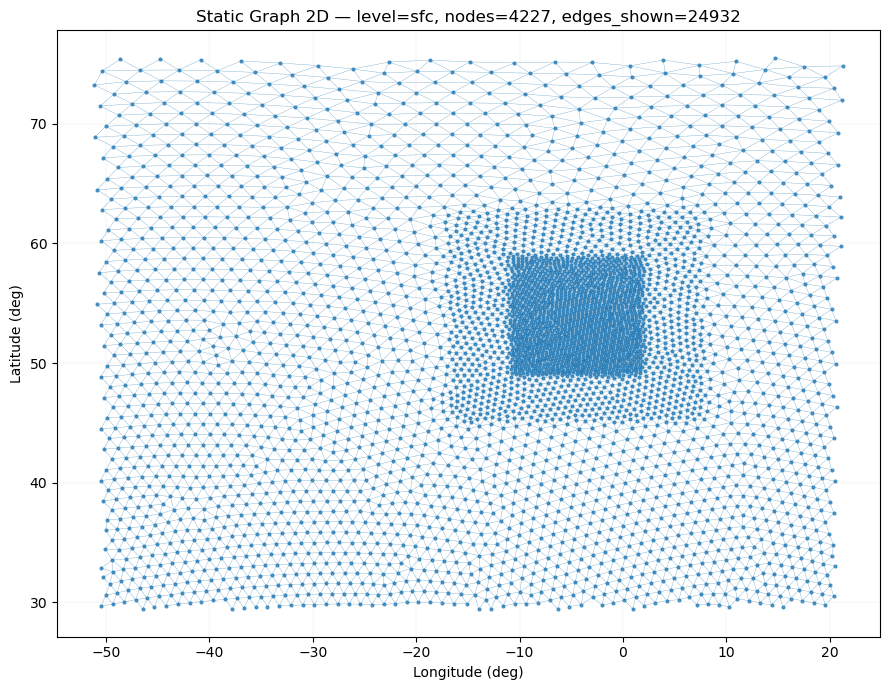

In [11]:
NPZ_PATH  = Path(summary["out"])
LVL_NAME  = "sfc"      # choose level by name
MAX_EDGES = 30_000
DRAW_NODES = True
NODE_SIZE  = 4
ALPHA_NODES = 0.7
ALPHA_EDGES = 0.35

npz = np.load(NPZ_PATH, allow_pickle=True)
lon = np.array(npz["coord_lon"], dtype=np.float32)
lat = np.array(npz["coord_lat"], dtype=np.float32)
edge_index_horiz = np.array(npz["edge_index_horiz"], dtype=np.int32)
edge_level = np.array(npz["edge_level"], dtype=np.int16).reshape(-1)
levels = [str(x) for x in npz["levels"]]
level_offsets = np.array(npz["level_offsets"], dtype=np.int32)
N_mesh = int(npz["N_mesh"])
L = int(npz["L"])
horiz_edge_ptr = np.array(npz["horiz_edge_ptr"], dtype=np.int32) if "horiz_edge_ptr" in npz.files else None

if LVL_NAME not in levels:
    raise ValueError(f"Level '{LVL_NAME}' not in {levels}")
lvl = levels.index(LVL_NAME)

# Slice edges for this level
if horiz_edge_ptr is not None and len(horiz_edge_ptr) == L + 1:
    start, end = int(horiz_edge_ptr[lvl]), int(horiz_edge_ptr[lvl+1])
    eidx = edge_index_horiz[:, start:end]
else:
    mask = (edge_level == lvl)
    eidx = edge_index_horiz[:, mask]

Eh_lvl = eidx.shape[1]
if Eh_lvl > MAX_EDGES:
    rng = np.random.default_rng(0)
    sel = rng.choice(Eh_lvl, size=MAX_EDGES, replace=False)
    eidx = eidx[:, sel]

# Convert to base-mesh indices
offset = int(level_offsets[lvl])
src = np.clip(eidx[0] - offset, 0, N_mesh-1)
dst = np.clip(eidx[1] - offset, 0, N_mesh-1)

# Build segments (with NaNs to separate)
xseg = np.empty(eidx.shape[1]*3, dtype=np.float32)
yseg = np.empty_like(xseg)
xseg[0::3] = lon[src]; xseg[1::3] = lon[dst]; xseg[2::3] = np.nan
yseg[0::3] = lat[src]; yseg[1::3] = lat[dst]; yseg[2::3] = np.nan

plt.figure(figsize=(9,7))
plt.plot(xseg, yseg, linewidth=0.25, alpha=ALPHA_EDGES)

if DRAW_NODES:
    idx_nodes = np.arange(N_mesh, dtype=np.int32)
    if N_mesh > 6000:
        rng = np.random.default_rng(1)
        idx_nodes = np.sort(rng.choice(N_mesh, size=6000, replace=False))
    plt.scatter(lon[idx_nodes], lat[idx_nodes], s=NODE_SIZE, alpha=ALPHA_NODES)

plt.title(f"Static Graph 2D — level={LVL_NAME}, nodes={N_mesh}, edges_shown={eidx.shape[1]}")
plt.xlabel("Longitude (deg)"); plt.ylabel("Latitude (deg)")
plt.grid(True, linewidth=0.3, alpha=0.3)
plt.tight_layout(); plt.show()

In [12]:
from mpl_toolkits.mplot3d.art3d import Line3DCollection

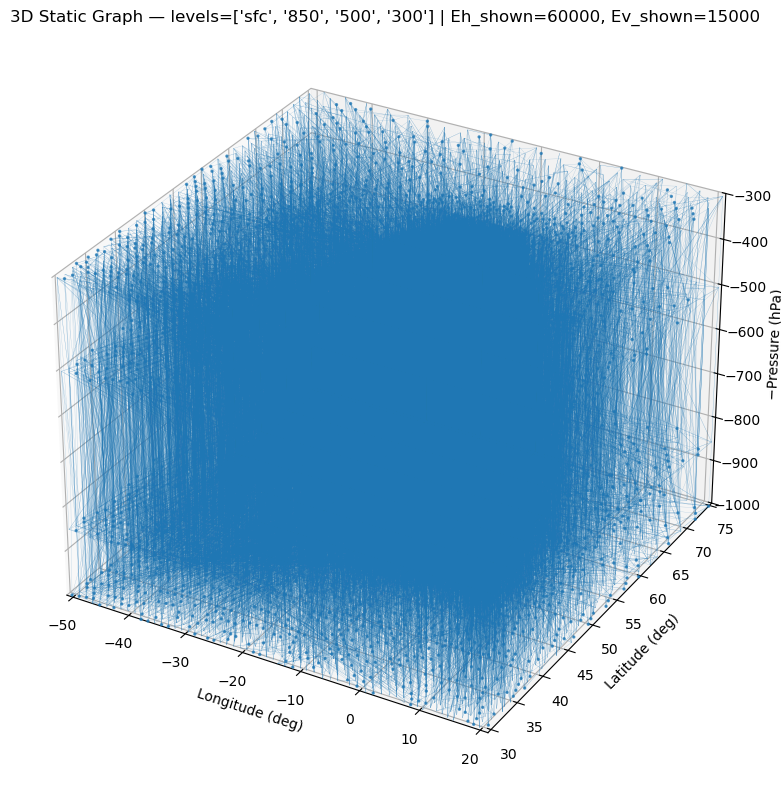

In [13]:
NPZ_PATH = Path(summary["out"])
MAX_H_EDGES = 60_000
MAX_V_EDGES = 15_000
DRAW_NODES_3D = True
MAX_3D_NODES  = 6_000
NODE_SIZE_3D  = 2
ALPHA_EDGES   = 0.35
ALPHA_NODES   = 0.7

npz = np.load(NPZ_PATH, allow_pickle=True)
lon = np.array(npz["coord_lon"], dtype=np.float32)
lat = np.array(npz["coord_lat"], dtype=np.float32)
N_mesh = int(npz["N_mesh"])
levels = [str(x) for x in npz["levels"]]
node2mesh  = np.array(npz["node2mesh"], dtype=np.int32)
node2level = np.array(npz["node2level"], dtype=np.int8)
edge_index_horiz = np.array(npz["edge_index_horiz"], dtype=np.int32)
edge_index_vert  = np.array(npz["edge_index_vert"],  dtype=np.int32)

# pressures for z-axis; sfc -> 1000 hPa
pressures = []
for lv in levels:
    s = str(lv); digits = "".join(ch for ch in s if ch.isdigit())
    pressures.append(int(digits) if digits else 1000)
pressures = np.array(pressures, dtype=np.int32)

# 3D coords per graph node
x3d = lon[node2mesh]; y3d = lat[node2mesh]; z3d = -pressures[node2level]

rng = np.random.default_rng(0)
Eh = edge_index_horiz.shape[1]
if Eh > MAX_H_EDGES:
    sel_h = np.sort(rng.choice(Eh, size=MAX_H_EDGES, replace=False)); eidx_h = edge_index_horiz[:, sel_h]
else:
    eidx_h = edge_index_horiz
Ev = edge_index_vert.shape[1]
if Ev > MAX_V_EDGES:
    sel_v = np.sort(rng.choice(Ev, size=MAX_V_EDGES, replace=False)); eidx_v = edge_index_vert[:, sel_v]
else:
    eidx_v = edge_index_vert

src_h, dst_h = eidx_h[0], eidx_h[1]
segs_h = np.stack([np.stack([x3d[src_h], y3d[src_h], z3d[src_h]], axis=1),
                   np.stack([x3d[dst_h], y3d[dst_h], z3d[dst_h]], axis=1)], axis=1)
src_v, dst_v = eidx_v[0], eidx_v[1]
segs_v = np.stack([np.stack([x3d[src_v], y3d[src_v], z3d[src_v]], axis=1),
                   np.stack([x3d[dst_v], y3d[dst_v], z3d[dst_v]], axis=1)], axis=1)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')
ax.add_collection(Line3DCollection(segs_h, linewidths=0.2, alpha=ALPHA_EDGES))
ax.add_collection(Line3DCollection(segs_v, linewidths=0.2, alpha=ALPHA_EDGES))

if DRAW_NODES_3D:
    N_total = x3d.shape[0]
    if N_total > MAX_3D_NODES:
        idx = np.sort(rng.choice(N_total, size=MAX_3D_NODES, replace=False))
    else:
        idx = np.arange(N_total, dtype=np.int32)
    ax.scatter(x3d[idx], y3d[idx], z3d[idx], s=NODE_SIZE_3D, alpha=ALPHA_NODES)

ax.set_xlabel("Longitude (deg)"); ax.set_ylabel("Latitude (deg)"); ax.set_zlabel("−Pressure (hPa)")
ax.set_title(f"3D Static Graph — levels={levels} | Eh_shown={segs_h.shape[0]}, Ev_shown={segs_v.shape[0]}")
mins = np.minimum(segs_h.reshape(-1,3).min(axis=0), segs_v.reshape(-1,3).min(axis=0))
maxs = np.maximum(segs_h.reshape(-1,3).max(axis=0), segs_v.reshape(-1,3).max(axis=0))
ax.set_xlim(mins[0], maxs[0]); ax.set_ylim(mins[1], maxs[1]); ax.set_zlim(mins[2], maxs[2])
plt.tight_layout(); plt.show()

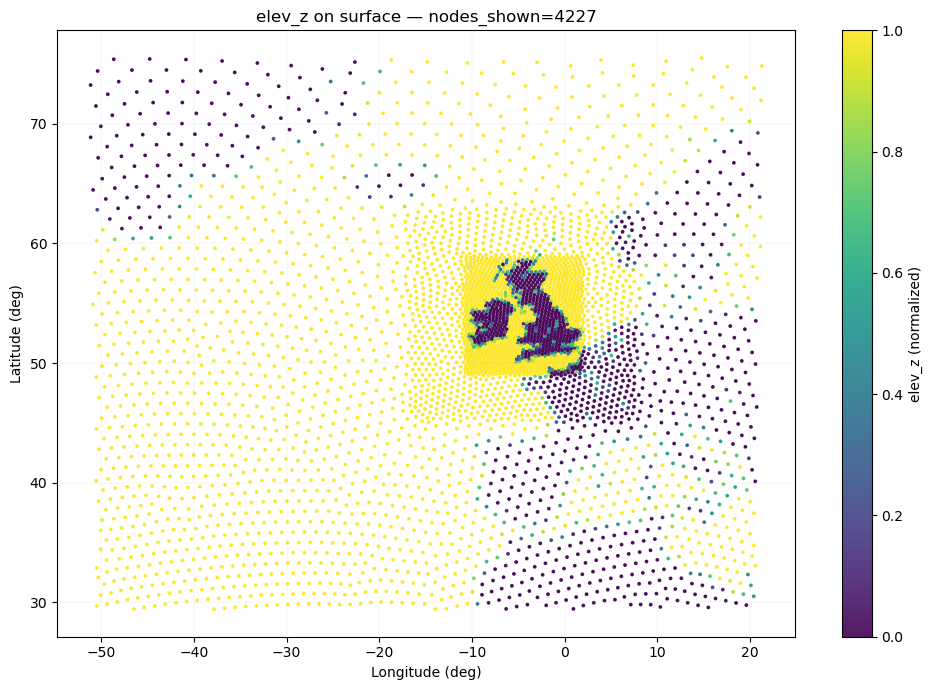

DEM channel idx: 3 (channels: ['elev_z', 'slope_z', 'relief_z', 'water_bin'])
DEM stats: min=0.0000  max=1.0000  std=0.4283


In [ ]:
NPZ_PATH = Path(summary["out"])

SURFACE_LEVEL_NAME = "sfc"
MAX_SURF_NODES = 40_000
NODE_SIZE = 3
ALPHA = 0.9

npz = np.load(NPZ_PATH, allow_pickle=True)
lon = np.array(npz["coord_lon"], dtype=np.float32)
lat = np.array(npz["coord_lat"], dtype=np.float32)
static_geo = np.array(npz["static_geo_mesh"], dtype=np.float32)   # [N_mesh, 4]
meta = json.loads(npz["meta"][0]) if hasattr(npz["meta"], "__len__") else {}

channels = meta.get("static_channels_geo", ["elev_z","slope_z","relief_z","water_bin"])
dem_idx = channels.index("water_bin") if "water_bin" in channels else 0
DEM_like = static_geo[:, dem_idx]  # нормалізована висота (з DEM-каналу)

N_mesh = int(npz["N_mesh"])
levels = [str(x) for x in npz["levels"]]
if SURFACE_LEVEL_NAME not in levels:
    raise ValueError(f"Surface level '{SURFACE_LEVEL_NAME}' not in {levels}")

rng = np.random.default_rng(1)
idx = np.arange(N_mesh, dtype=np.int32)
if N_mesh > MAX_SURF_NODES:
    idx = np.sort(rng.choice(N_mesh, size=MAX_SURF_NODES, replace=False))

plt.figure(figsize=(10, 7))
sc = plt.scatter(lon[idx], lat[idx], s=NODE_SIZE, alpha=ALPHA, c=DEM_like[idx])  # default colormap
plt.colorbar(sc, label="elev_z (normalized)")
plt.title(f"elev_z on surface — nodes_shown={idx.size}")
plt.xlabel("Longitude (deg)"); plt.ylabel("Latitude (deg)")
plt.grid(True, linewidth=0.3, alpha=0.3)
plt.tight_layout(); plt.show()

# швидка діагностика
print(f"DEM channel idx: {dem_idx} (channels: {channels})")
print(f"DEM stats: min={float(DEM_like.min()):.4f}  max={float(DEM_like.max()):.4f}  std={float(DEM_like.std()):.4f}")